# Backtester Core Engine

**Owner:** James  
**Version:** 2.0 (Feb 13, 2026)  

Core backtesting engine for evaluating sports betting strategies.  
All logic is imported from `src/cuic_quant/backtest/backtester_backend.py`.  
See `docs/reference/strategy-interface.md` for the strategy function contract.

## Output Format

| Column | Type | Description |
|--------|------|-------------|
| timestamp | datetime | When trade happened |
| game | str | "Home vs Away" |
| action | str | 'BUY_HOME' or 'BUY_AWAY' |
| bet_size | float | Dollars bet |
| odds | float | Decimal odds used |
| outcome | str | 'WIN' or 'LOSS' |
| pnl | float | Profit/loss for this trade |
| cumulative_pnl | float | Running total P&L |
| bankroll | float | Current bankroll after trade |

In [1]:
import sys
from pathlib import Path

# Ensure src/ is importable when running from tools/ directory
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "tools":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from cuic_quant.backtest import (
    load_backtest_data,
    backtest,
    always_bet_away,
    validate_backtest_results,
    display_extended_metrics,
    plot_performance,
)

## Configuration

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
DUMMY_CSV = DATA_DIR / "dummy_backtest_input.csv"

## Load Data

In [3]:
data = load_backtest_data("2026-01-01", "2026-01-31", csv_path=DUMMY_CSV)
print(f"Games loaded: {len(data)}")
data.head()

Loaded 25 rows from dummy_backtest_input.csv.
Games loaded: 25


,timestamp,game,home_team,away_team,home_odds,away_odds,home_win
0,2026-01-01,Lakers vs Celtics,Lakers,Celtics,1.95,2.05,1
1,2026-01-02,Warriors vs Heat,Warriors,Heat,1.80,2.20,1
2,2026-01-03,Bucks vs Nets,Bucks,Nets,1.65,2.45,1
3,2026-01-04,Nuggets vs Suns,Nuggets,Suns,2.10,1.85,0
4,2026-01-05,76ers vs Knicks,76ers,Knicks,1.90,2.00,1


## Strategy

Using the built-in `always_bet_home` test strategy.

To use your own strategy, replace the assignment below:

```python
def my_strategy(row, context=None):
    return {"action": "BUY_HOME", "confidence": 0.8, "size": 50.0}

strategy = my_strategy
```

See `docs/reference/strategy-interface.md` for the full contract.

In [4]:
strategy = always_bet_away

## Run Backtest

In [5]:
results = backtest(data, strategy, initial_bankroll=10000.0)
print(f"Total trades: {len(results)}")
results

Total trades: 25


,timestamp,game,action,bet_size,odds,outcome,pnl,cumulative_pnl,bankroll
0,2026-01-01,Lakers vs Celtics,BUY_AWAY,100.0,2.05,LOSS,-100.0,-100.0,9900.0
1,2026-01-02,Warriors vs Heat,BUY_AWAY,100.0,2.20,LOSS,-100.0,-200.0,9800.0
2,2026-01-03,Bucks vs Nets,BUY_AWAY,100.0,2.45,LOSS,-100.0,-300.0,9700.0
3,2026-01-04,Nuggets vs Suns,BUY_AWAY,100.0,1.85,WIN,85.0,-215.0,9785.0
4,2026-01-05,76ers vs Knicks,BUY_AWAY,100.0,2.00,LOSS,-100.0,-315.0,9685.0
5,2026-01-06,Celtics vs Heat,BUY_AWAY,100.0,2.30,LOSS,-100.0,-415.0,9585.0
6,2026-01-07,Lakers vs Warriors,BUY_AWAY,100.0,1.78,WIN,78.0,-337.0,9663.0
7,2026-01-08,Nets vs Bucks,BUY_AWAY,100.0,1.60,WIN,60.0,-277.0,9723.0
8,2026-01-09,Suns vs 76ers,BUY_AWAY,100.0,2.00,LOSS,-100.0,-377.0,9623.0
9,2026-01-10,Knicks vs Nuggets,BUY_AWAY,100.0,1.72,WIN,72.0,-305.0,9695.0


## Summary Statistics

In [6]:
if len(results) > 0:
    wins = (results["outcome"] == "WIN").sum()
    losses = (results["outcome"] == "LOSS").sum()
    win_rate = wins / len(results)
    final_pnl = results["cumulative_pnl"].iloc[-1]
    final_bankroll = results["bankroll"].iloc[-1]

    print(f"Win Rate:        {win_rate:.1%} ({wins}W / {losses}L)")
    print(f"Total P&L:       ${final_pnl:,.2f}")
    print(f"Final Bankroll:  ${final_bankroll:,.2f}")
    print(f"ROI:             {final_pnl / 10000:.1%}")
else:
    print("No trades executed.")

Win Rate:        40.0% (10W / 15L)
Total P&L:       $-677.00
Final Bankroll:  $9,323.00
ROI:             -6.8%


## Validate Results

Run the full validation suite to check schema, math correctness, and data leakage.

The validator runs **11 checks** across three categories:

### 1. Schema Validation (5 checks)
- **Column names** — output has exactly the 9 required columns in the correct order.
- **Valid actions** — every action is `BUY_HOME` or `BUY_AWAY` (no `SKIP` rows in output).
- **Valid outcomes** — every outcome is `WIN` or `LOSS`.
- **Positive bet sizes** — no zero or negative bets.
- **Valid odds** — all decimal odds are > 1.0.

### 2. Math Correctness (4 checks)
- **PnL formula** — WIN trades pay `bet_size * (odds - 1)`, LOSS trades pay `-bet_size`.
- **Cumulative PnL** — the `cumulative_pnl` column is a correct running sum of `pnl`.
- **Bankroll tracking** — `bankroll = initial_bankroll + cumulative_pnl` at every row.
- **No overbetting** — no bet exceeds the bankroll available at the time of the bet.

### 3. Data Leakage Detection (2 checks)
- **Outcome consistency** — each trade's outcome is cross-referenced against the original input data's `home_win` column. If a strategy somehow produced outcomes that don't match the actual game results, this catches it (e.g., a bug that lets the strategy "see" the outcome before betting).
- **Chronological order** — trades must be in timestamp order. Out-of-order trades could indicate the strategy accessed future game data to make decisions.

> **Why leakage checks matter:** A backtester bug that leaks future information (e.g., passing `home_win` to the strategy) would produce unrealistically high win rates. These checks verify the backtester correctly strips outcome data before calling the strategy.

In [7]:
report = validate_backtest_results(results, data)

if report["passed"]:
    print(f"PASSED: {report['checks_passed']}/{report['checks_run']} checks passed")
else:
    print(f"FAILED: {report['checks_passed']}/{report['checks_run']} checks passed")
    for f in report["failures"]:
        print(f"  - {f}")

PASSED: 12/12 checks passed


## Performance Metrics

Extended metrics from Ben's `cuic_quant.metrics` module plus additional risk/reward statistics.

In [8]:
display_extended_metrics(results)

       EXTENDED PERFORMANCE METRICS
  Sharpe Ratio:             -4.693
  Sortino Ratio:             0.000
  Max Drawdown:              6.9%
  Profit Factor:             0.549
  Average Win:          $    82.30
  Average Loss:         $  -100.00
  Win/Loss Ratio:            0.823
  Expected Value/Bet:   $   -27.08
  Longest Win Streak:            2
  Longest Loss Streak:           3
  Best Trade:           $   110.00
  Worst Trade:          $  -100.00


## Performance Graphs

Cumulative P&L, drawdown, P&L distribution, and trade outcomes.

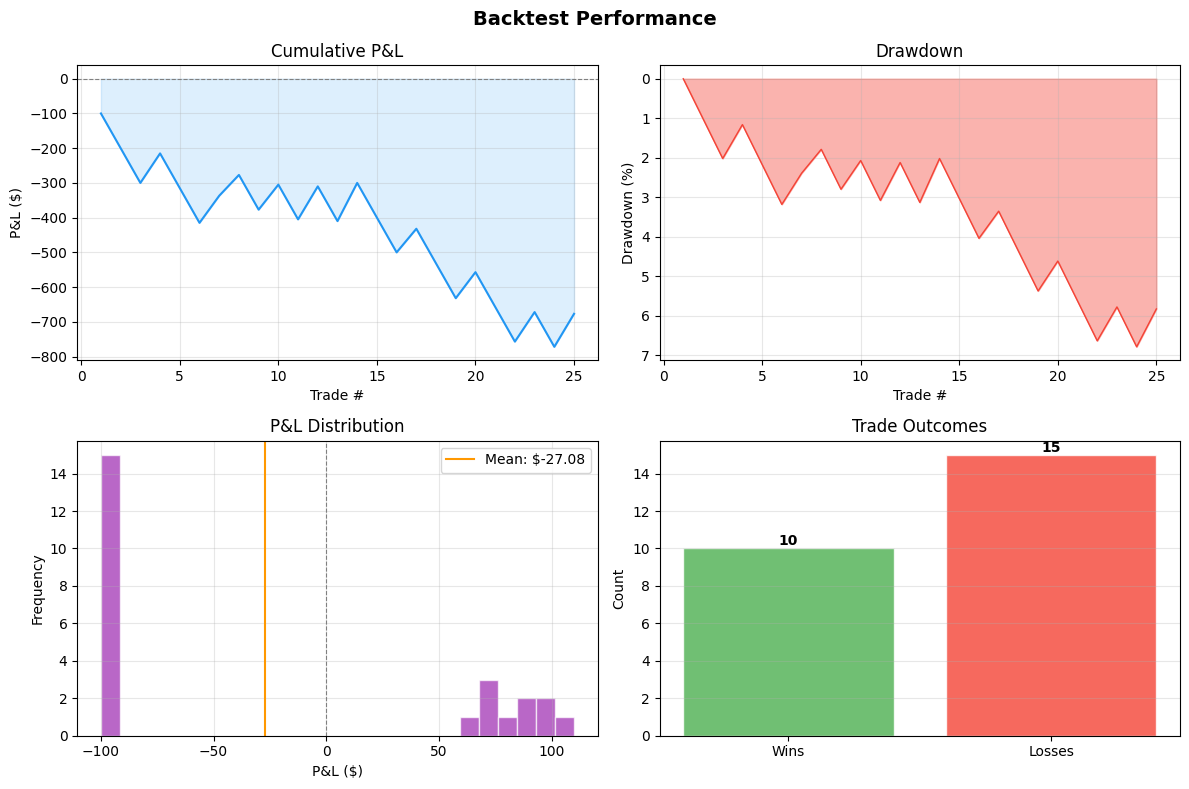

In [9]:
plot_performance(results)